# Condensator Ontwerpopdracht

Bij het vak elektromagnetisme zullen jullie in de eerste paar weken diep ingaan op de elektrostatica. Parallel hieraan zullen we bij het vak DEF-D, naast de fysieke ontwerpopdrachten en colleges, deze simulatie-ontwerpopdracht behandelen. Deze simulatie-opdracht is weer nauw verwoven met de tweede fysieke ontwerpopdracht die in week 3.3 gegeven wordt. Je moet het grootste deel van deze simulatie opdracht afronden voordat je aan de fysieke ontwerpopdracht van week 3.3 begint. Het laatste stuk van deze simulatie opdracht maak je na afloop van de fysieke opdracht. De deadline voor het inleveren van deze simulatie-opdracht is in week 3.4

Je werkt bij deze opdracht in teams die wij indelen. Zoek op Brightspace op met wie je samenwerkt en leg via email contact. Maak goede afspraken over hoe je samen gaat werken.

In deze simulatie opdracht beginnen we met een aantal simulaties van verschillende situaties, die jullie daarna zullen interpreteren. Daarna zal wat essentiële voorbereiding op de tweede fysieke ontwerpopdracht besproken worden. En als laatste zal dieper ingegaan worden op hoe jullie metingen van de tweede ontwerpopdracht afwijken van de theorie.

De opdracht bestaat uit de volgende sub-opdrachten die je moet doen voordat je begint aan de fysieke ontwerpopdracht van week 3.3:
1) Een puntlading in de oorsprong.
2) Een uniform geladen schijf bestaande uit puntladingen.
3) Een geladen schijf op een constant potentiaal.
4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$.
5) Voorbereidende opdracht voor de DEF ontwerpopdracht.

Na de fysieke ontwerpopdracht van week 3.3 kan je ten slotte het laatste deel doen:

6) Reflectie opdracht voor na de fysieke ontwerpopdracht.

De opdracht wordt volledig online gedaan, er zullen hiervoor dus ook geen specifieke werkcolleges voor zijn ingeroosterd. Als jullie vragen hebben kunnen jullie die mailen naar het DEF e-mailadres: DEF-TNW@tudelft.nl. Deze opdracht wordt in week 3.4 beoordeeld en herkansingen zijn in week 3.5, zie de studiehandleiding voor details.
   
Technische Instructies:
- Git clone (als nog niet gedaan) het DEF repo en maak een branch voor werken aan deze opdracht. Nodig je groepsgenoot uit als collaborator. Hiervoor staat een manual op brightspace.
- Dit notebook maakt gebruik van een aantal functies die in het bestand ```functions_electrostatics.py``` staan. Dit bestand moet in dezelfde map (folder) staan als dit notebook. Als je git clone doet, gaat dat automatisch goed, maar verplaats dit notebook dus niet naar een andere map, mail het niet naar een mede-student, etc. Als je niet weet wat een map (folder) en een bestand is, bekijk dan [deze tutorial](https://teachbooks.io/files-and-folders/EN/intro.html).

Onderwijs Instructies:
- Beantwoord de vragen die in dit notebook voor komen direct in dit notebook.
- Als je iets moet printen op het scherm als antwoord op een vraag, doe dit op een gestructureerde manier met als dat relevant is de eenheid erbij, zoals je geleerd is bij het Inleidend Practicum.
- Vermijd 'hardcoden' waar mogelijk.
- Bij elke code cel staat aangegeven of jij hem moet aanpassen of alleen runnen. Lees bij cellen die je moet runnen, maar niet hoeft aan te passen, goed de code door om daarvan te leren en te gebruiken in de cellen die je wel moet aanpassen.

Elektrostatica Opmerkingen:
- In deze opdracht zullen jullie verschillende problemen bestuderen die as-symmetrie hebben. De opdrachten zullen daardoor, cilindrische coördinaten ($r$,$\phi$,$z$) gebruiken, waarbij $r$ de afstand tot de $z$ as is, $z$ de hoogte en $\phi$ de hoek met de $x$-as. Alle gebruikte problemen zullen ook in de $\phi$ richting symmetrisch zijn en die coördinaat zal dus niet uitmaken.
- Voor elke sub-opdracht zal eerst het potentiaal bepaald worden en daarna zal het elektrische veld bepaald worden met de "finite difference" methode. Dit is een methode om de afgeleide te nemen van een dataset. Deze methode is geen onderdeel van de leerdoelen van het vak en komt later in je studie aan bod. We gebruiken "finite difference" hier als gereedschap en als voorbeeld van wat je later nog tegen gaat komen.



Vul de informatie in deze cel in:

| Groep: XX     |  |
| :-------------|:-------------|
| Thijs Spilt | 6540619 |
| Ties Langeraar | 6541798 |

In [12]:
# Run deze cel, pas deze niet aan
import numpy as np
import matplotlib.pyplot as plt
from functions_electrostatics import *
#from IPython import display
from IPython.display import Image, display
from scipy.optimize import curve_fit

epsilon0 = 8.854e-12  # permittiviteit van vacuum (F/m)

"""============================================================================================
We first define the size of the domain of calculation and spatial discretization of the domain
"""

# Grid van het rekendomein; het veld wordt berekend in het (r,z)-vlak (asymmetrie):
width_domain = 5  # (m)
height_domain = width_domain  # maximum afstand van de schijf tot de grond, boven en beneden (m)
grid_step = 0.1  # grid stap grootte (m)

### 1) Een puntlading in de oorsprong

In deze opdracht gaan we in op een numerieke benadering van het potentiaal en elektrische veld rond een puntlading in de oorsprong. 

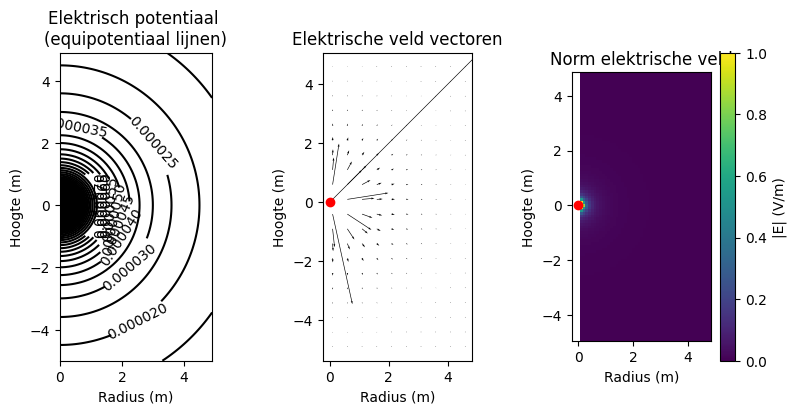

In [13]:
# Run deze cel, pas de cel niet aan
charge_one_point = 1e-14  # lading van 1 punt (C)

r, z, B = initialize_plane_grid_for_pt_charge_at_origin(height_domain, width_domain, grid_step)
V = calculate_V_point_charge_at_origin(charge_one_point, r, z)

Er, Ez, normE = compute_E_pt_charge(V, B, grid_step)  # gebruik de centered finite-difference method
# met Er de r-component, Ez de z-component en normE de norm van het elektrische veld

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_pt_charge_at_origin(Ez, Er, normE, V, r, z, grid_step)


##### Vraag 1a Het potentiaal rond een puntlading

1. Bepaal welke index correspondeert met $z = 0$ m.
2. Plot de log van het potentiaal tegen de log van de straal.
3. Fit de log van het potentiaal met de log van de straal.
4. Print het exponent op een nette manier.

De exponent die gevonden is door de curvefit is -1.0 dit komt overeen met de verwachte waarde.


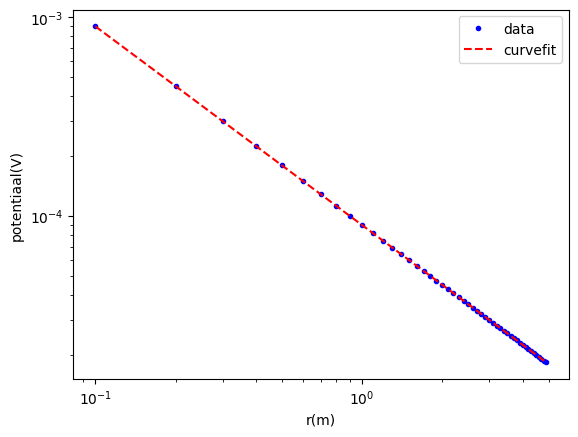

In [14]:
z_0 = find_idx_nearest(z,0) # z = 0 vinden

V_plot = V[z_0, :] #nemen op z = 0
r_no_null = r[1:] #nullen weghalen om geen inf te krijgen
V_no_null = V_plot[1:]


def testfit(r,a,b): #lineair om de log te vinden
    return a*r + b

vals, cov = curve_fit(testfit, np.log(r_no_null), np.log(V_no_null))
print('De exponent die gevonden is door de curvefit is', vals[0], 'dit komt overeen met de verwachte waarde.')

x_test=np.linspace(min(r_no_null),max(r_no_null),1000)

def macht_fit(r,a,b): #om de plot te kunnen maken
    return a*r**b

plt.figure()
plt.loglog(r_no_null,V_no_null, 'b.', label = 'data')
plt.loglog(x_test,macht_fit(x_test, np.e**vals[1], vals[0]), 'r--', label = 'curvefit')
plt.xlabel('r(m)')
plt.ylabel('potentiaal(V)')
plt.legend()
plt.show()


##### Vraag 1b Het elektrische veld rond een puntlading
1. Voer van vraag 1a 2 tot 4 uit voor het elektrische veld.

De exponent die gevonden is door de curvefit is -1.9110653435036604 dit komt in de buurt van, maar niet overeen met de verwachtte waarde van -2


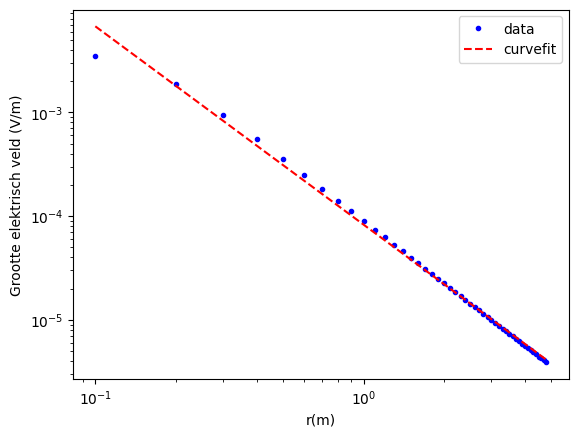

In [15]:
E_plot = normE[z_0, :] #grootte E op z = 0


def testfit(r,a,b):
    return a*r + b

vals_2, cov_2 = curve_fit(testfit, np.log(r_for_E), np.log(E_plot))
print('De exponent die gevonden is door de curvefit is', vals_2[0], 'dit komt in de buurt van, maar niet overeen met de verwachtte waarde van -2')

x_test=np.linspace(min(r_for_E),max(r_for_E),1000)

def macht_fit(r,a,b): #om de plot te kunnen maken
    return a*r**b

plt.figure()
plt.loglog(r_for_E,E_plot, 'b.', label = 'data')
plt.loglog(x_test,macht_fit(x_test, np.e**vals_2[1], vals_2[0]), 'r--', label = 'curvefit')
plt.legend()
plt.xlabel('r(m)')
plt.ylabel('Grootte elektrisch veld (V/m)')
plt.show()

### 2) Een uniform geladen schijf bestaande uit puntladingen

In de code hieronder wordt een geladen schijf gemaakt via het superpositie principe. Dit wordt gedaan door een rooster van punten in de ruimte te creëren, alle punten die voldoen aan $z = 0$ m en $r < R$ krijgen een lading charge_one_point en vanuit hier wordt het potentiaal bepaald. Hier is de $z$-as de as van de schijf en de r as de afstand tot de $z$-as.



In [16]:
# In vraag 2.1 wordt naar deze cel verwezen.
disk_radius = 1 # (m)
grid_step = 0.1  # (m)
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen
height_domain = 4


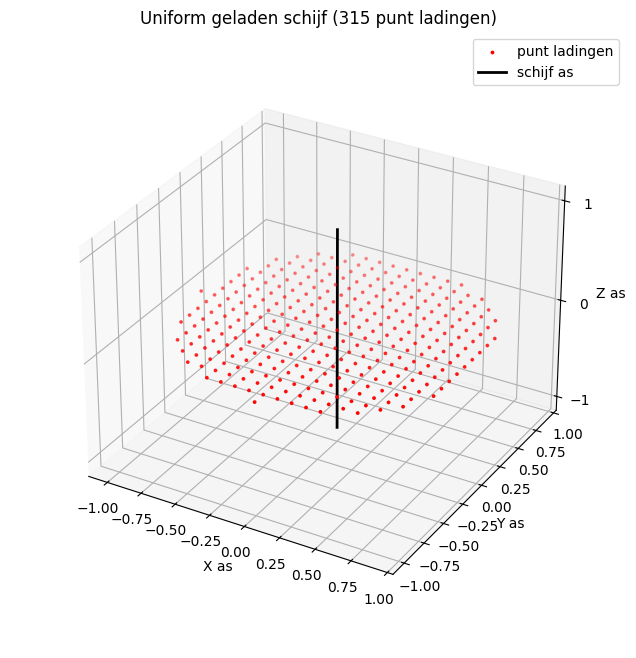

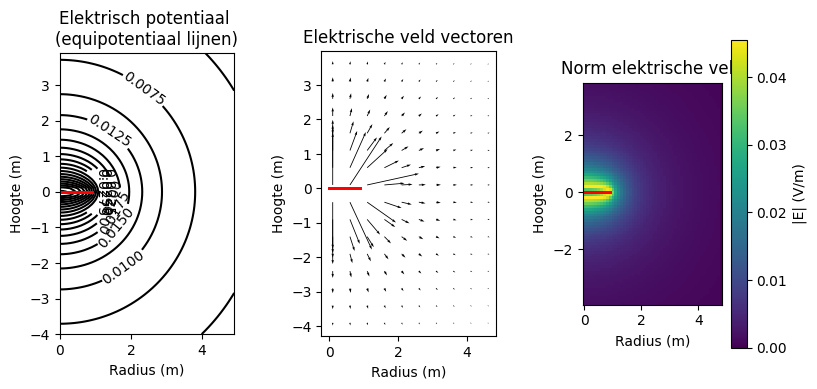

In [17]:
# Kies uit deze cel een van de variabelen en verander die in de cel hierboven pas deze cel zelf niet aan.
r, z, B = initialize_plane_grid_for_uniformly_charged_disk(height_domain, width_domain, grid_step)

idx_z_zero = np.where(abs(z) < 1e-10)[0]
z_coord_DISK = 0  # (m) positie van de schijf op de z-as
inter_charge_distance = grid_step  # (m) afstand tussen punt ladingen

V, number_point_charges_on_disk = calculate_V_disk_at_origin_uniform_surface_charge_density(z_coord_DISK, charge_one_point, disk_radius, inter_charge_distance, r, z)
Er, Ez, normE = compute_E_disk(V, B, grid_step)  # gebruik de centered finite-difference method

r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_coord_DISK, z_coord_DISK)

#### Vraag 2a

In deze vraag gaan jullie achterhalen wat de variabelen die aan het begin van opgave 2 worden geïnitialiseerd betekenen voor de nauwkeurigheid en snelheid van de code.
Pas voor deze vraag de code die net onder het kopje vraag 2 staat aan. Run dan die cel en de cel daaronder opnieuw om het resultaat van je aanpassing te zien.
1. Wat betekent de disk radius variabele die in de bovenste cel geïnitialiseerd wordt, wat gebeurt er als disk radius naar 0 gaat?
2. Wat betekent gridstep en wat voor impact heeft deze variabele op de simulatie?
3. Pak uit de tweede code cel in opdracht 2 een andere variabelen en onderzoek wat deze variabele doet en wat voor impact die heeft op de simulatie.

##### Antwoorden 2a

1: De disk radius is de radius van de disk, oftewel radius van de cirkel waarin de ladingen verdeeld zijn. Als deze naar nul gaat, zijn er steeds minder ladingen binnen de disk te passen, totdat er een puntlading over blijft. Als je de disk dan nog kleiner maakt, verdwijnt alle lading.

2: De grid-step geeft aan hoe dicht de ladingen op elkaar zitten. Als je deze verlaagt, kunnen er meer ladingen binnen dezelfde disk radius zitten. Dit zorgt voor een groter veld en potentiaal. Ook zorgt het bij de simulatie op een langere laadtijd.

3: Height domain geeft aan hoe groot de z maximaal en minimaal kan zijn, wat vooral invloed heeft op de figuren aan de onderkant.

#### Vraag 2b Oppervlakte lading

Pas de cel die je in vraag 2a hebt aangepast weer aan naar de originele waardes. Run hierna alle code cellen na vraag 2 weer opnieuw.
Het aantal punten dat gebruikt wordt om de schijf te creëren is number_point_charges_on_disk en de lading van een punt is charge_one_point in Coulomb.
1. Bereken en print de ladingsdichtheid $\sigma$ met een correcte eenheid.

In [18]:
opp_disc = np.pi*disk_radius**2
tot_lading = number_point_charges_on_disk * charge_one_point

ladingsdichtheid = tot_lading/opp_disc

print('De ladingsdichtheid op de disc is', ladingsdichtheid, 'C/m^2')

De ladingsdichtheid op de disc is 1.0026761414789406e-12 C/m^2


##### Vraag 2c

1. Plot het elektrische potentiaal langs de $r$ as ($z = 0$ m).
2. Plot het potentiaal op de rand van de schijf in hetzelfde figuur $V = \sigma R/(\pi \epsilon_0)$
(bekijk probleem 2.51 in het Griffiths' boek)
3. Plot het potentiaal in het centrum van de schijf in hetzelfde figuur $V = \sigma R/(2 \epsilon_0)$

0.05303296319962506


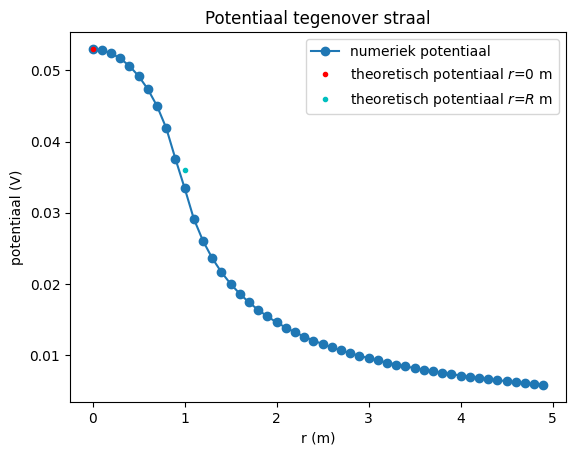

In [19]:
# Vul deze code aan zodat deze vraag 2.3 beantwoord.
idx_z_zero = find_idx_nearest(z,0)

V_0 =  V[idx_z_zero,0]# potentiaal op r = 0

V_R =  ladingsdichtheid*disk_radius/(np.pi*epsilon0)# potentiaal op de straal van de schijf

plt.title(f"Potentiaal tegenover straal")
plt.plot(r, V[idx_z_zero,:], "o-", label="numeriek potentiaal")
plt.plot(0, V_0, "r.", label="theoretisch potentiaal $r$=0 m")
plt.plot(disk_radius, V_R, "c.", label="theoretisch potentiaal $r$=$R$ m")
plt.legend()
plt.xlabel("r (m)")
plt.ylabel("potentiaal (V)")

print(V_0)


#### Vraag 2d

Het theoretische potentiaal op de as van een hele grote schijf ($R>>z$) is:
$V(z, r=0) = \frac{\sigma}{2\epsilon_0} \big( R - |z|\big)$
zie probleem 2.26 in het Griffiths boek.
1. Plot het numeriek berekend elektrische potentiaal op de $z$-as ($r=0$).
2. Plot het theoretische component van het potentiaal op de as van een schijf met ladingsdichtheid $\sigma$.
3. Sla deze plot op.


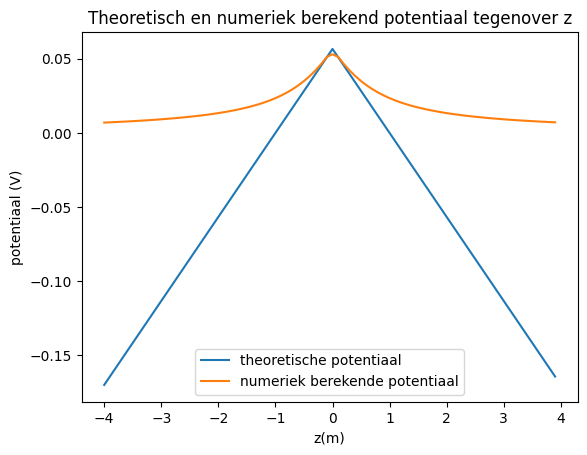

In [20]:
r_idx_0 = find_idx_nearest(r,0)

V_num = V[:,r_idx_0]

def V_theo(z):
    return (ladingsdichtheid/(2*epsilon0))*(disk_radius-np.abs(z))

plt.figure()
plt.plot(z, V_theo(z), label = 'theoretische potentiaal')
plt.plot(z ,V_num, label = 'numeriek berekende potentiaal')
plt.legend()
plt.xlabel('z(m)')
plt.ylabel('potentiaal (V)')
plt.title('Theoretisch en numeriek berekend potentiaal tegenover z')
plt.savefig('V_num_en_theo_tegenover_z_v2')
plt.show()

#### Vraag 2e

Het theoretische elektrische veld van een oneindig geladen oppervlakte is $|E| = \sigma/(2 \epsilon_0)$ (zie Example 2.5 in het Griffith boek).
1. Plot het z-component van het numeriek berekende elektrische veld op de as van de schijf ($r=0$).
2. Plot het theoretische elektrische veld voor een oneindig geladen oppervlak.
3. Sla deze plot ook op.

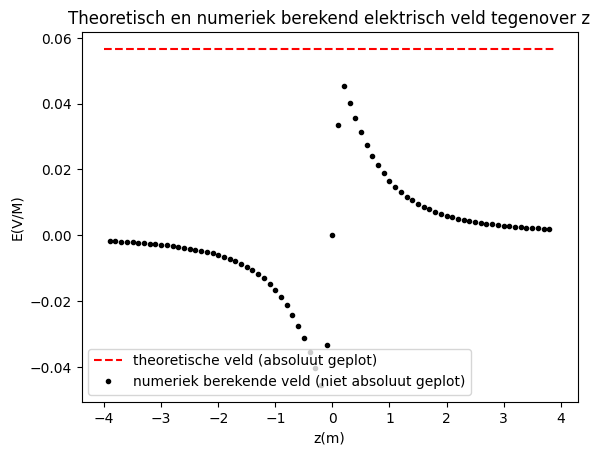

In [27]:
E_num = Ez[:,r_idx_0]
E_theo = np.ones(len(z))* (ladingsdichtheid/(2*epsilon0))

plt.figure()
plt.plot(z, E_theo, 'r--', label = 'theoretische veld (absoluut geplot)',)
plt.plot(z_for_E ,E_num, 'k.', label = 'numeriek berekende veld (niet absoluut geplot)')
plt.legend()
plt.xlabel('z(m)')
plt.ylabel('E(V/M)')
plt.title('Theoretisch en numeriek berekend elektrisch veld tegenover z')
plt.savefig('E_num_en_theo_tegenover_z_v2')
plt.show()

#### Vraag 2f
1. Waar benadert het elektrische veld van een uniform geladen schijf dat van een oneindig geladen plaat?
2. Beschrijf en verklaar de verschillen die je opvallen in de plot die je bij vraag 2e hebt gemaakt.

##### Antwoorden 2f

1: De velden benaderen elkaar bij een z met lim→0.

2: Het grootste verschil wat me opvalt is dat bij e de grafieken vrij overeenkomen, maar bij f is dit absoluut niet het geval. Te zien is dat de absolute waarde van het elektrisch veld bij een steeds grotere absolute waarde van z steeds kleiner wordt. Hiervoor is een verklaring dat hoe dichter het veld bij de disc zit, hoe groter het gedeelte van het Elektrisch veld is wat de disc in gaat. Als je dicht genoeg bij de disc komt gaat zo'n groot gedeelte van het veld door de disc, dat het bijna evenveel wordt als wanneer de disc oneindig groot zo zijn.


#### Vraag 2g

1. Pas helemaal bovenaan in vraag 2 de straal van de schijf aan.
2. Voer dan vragen 2d en 2e opnieuw uit.
3. Voeg de opgeslagen figuren hieronder toe.
4. Beschrijf de verschillen tussen de twee verschillende stralen.

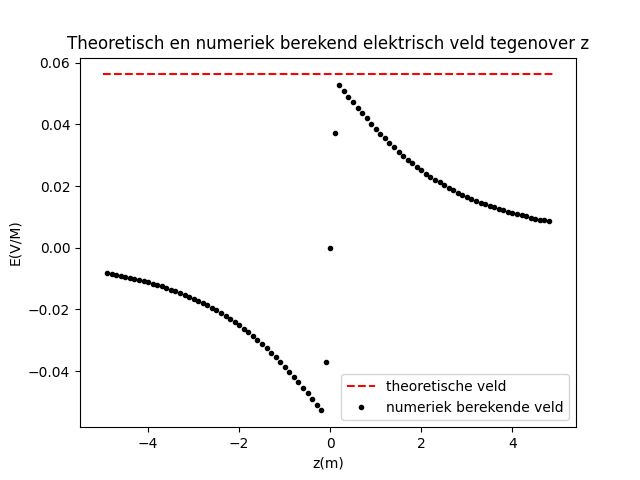

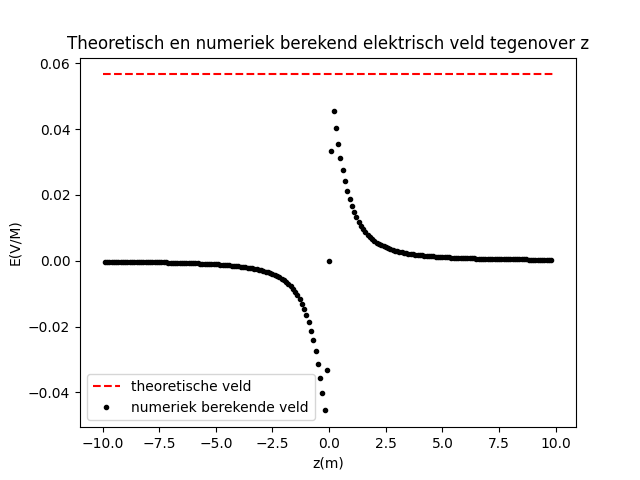

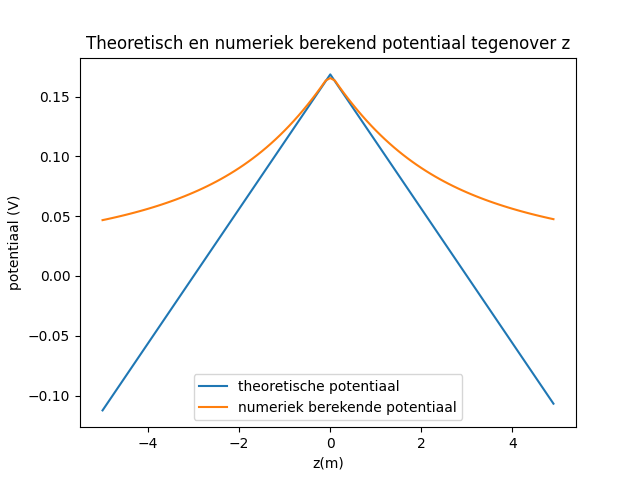

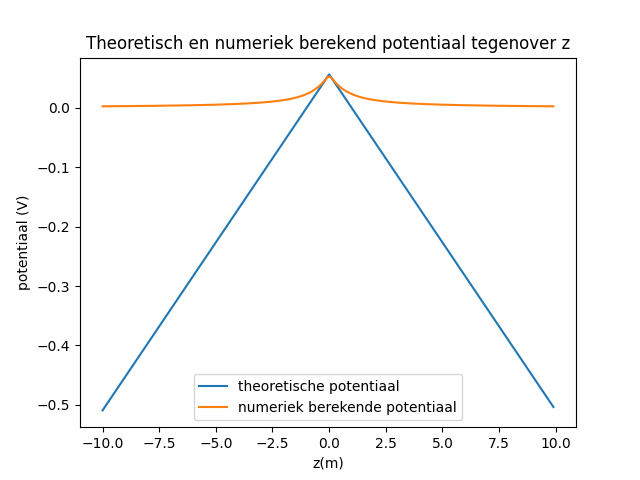

In [ ]:
display(Image("E_num_en_theo_tegenover_z.png"))
display(Image("E_num_en_theo_tegenover_z_v2.png"))
display(Image("V_num_en_theo_tegenover_z.png"))
display(Image("V_num_en_theo_tegenover_z_v2.png"))

##### Antwoorden 2g

Het verschil tussen de twee stralen is dat bij een kleinere straal de theoretische en numerieke lijnen veel eerder divergeren.

#### Vraag 2h
Het elektrische veld een afstand $z$ boven het midden van een uniform geladen schijf met een straal $R$ en oppervlakte lading $\sigma$ wordt gegeven door:
$$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$$
Zie probleem 2.6 in het boek van Griffith.

1. Wat moet de hoogte $z$ zijn boven de schijf zodat het elektrische veld door de schijf 10% is in vergelijking met dat van een oneindig geladen plaat?

Voeg hieronder je analytische uitwerking toe.

##### Antwoord 2h
$|E|_{theo} = \sigma/(2 \epsilon_0)$

$ \mathbf{E} = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$

$0.1 \cdot |E|_{theo} = \mathbf{E} \hat{\mathbf{z}}$

$0.1 \cdot \sigma/(2 \epsilon_0) = \frac{\sigma}{2\epsilon_0} \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$

$0.1 = \bigg[ 1- \frac{z}{\sqrt{R^2 + z^2}}\bigg] \hat{\mathbf{z}}$

Het is alleen in de z richting, dus

$0.1 = 1- \frac{z}{\sqrt{R^2 + z^2}} $

$-0.9 = - \frac{z}{\sqrt{R^2 + z^2}} $

$0.9\sqrt{R^2 + z^2} = z $

$0.81(R^2 + z^2) = z^2 $

$0.81R^2 + 0.81z^2 = z^2 $

$z^2 = \frac{0.81}{0.19} R^2$

$z = \sqrt{\frac{0.81}{0.19} R^2}$

### 3) Een geladen schijf op een constant potentiaal

We zullen nu het verschil bestuderen tussen een uniform geladen schijf en een geleidende schijf die op een bepaald potentiaal gehouden wordt.
De code hieronder lost numeriek de laplace vergelijking op voor een geleidende schijf op een constant potentiaal. Hieruit volgt het potentiaal in de ruimte.

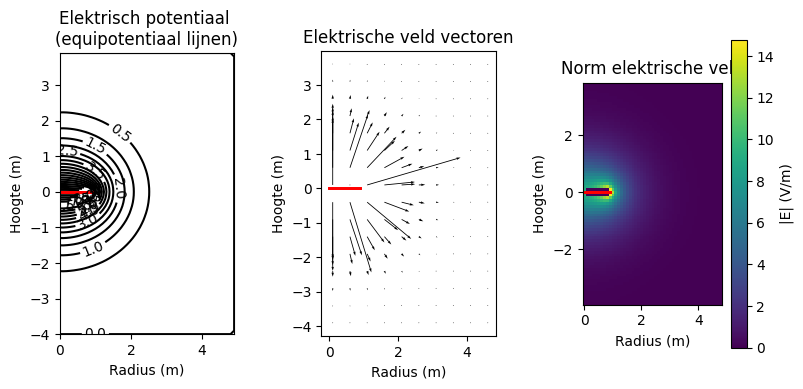

In [28]:
# Run deze cel pas deze niet aan.
V0 = 0  # electric potential at boundary of domain (V)

# Één schijf
z_pos_disk1 = 0  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = z_pos_disk1  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V1)

"""--------------------------------------------------------------------
Veldberekening voor een geleidende schijf
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V1, 1e-3)
Er, Ez, normE = compute_E_disk(V,B,grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)

#### Vraag 3a: De simulatie van het elektrische veld van een geleidende schijf op constant potentiaal

1. Plot de elektrische veld sterkte op de as van de schijf.
2. Print de norm van het elektrische veld op de as heel dicht bij het midden van de schijf, zorg hier voor een nette opmaak.

De norm heel dicht bij het midden van de schijf is: 9.15 V/m


Text(0.5, 0, 'z(m)')

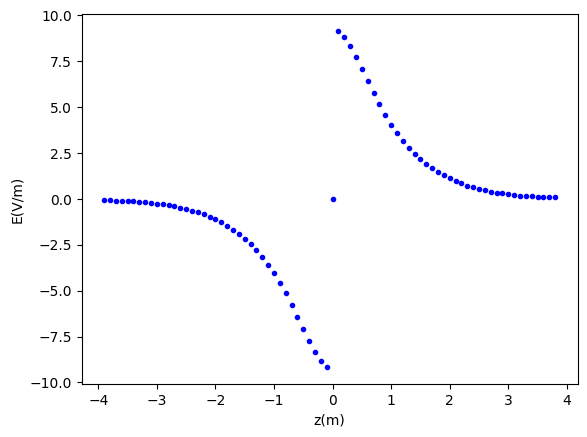

In [29]:
r_idx_0 = find_idx_nearest(r_for_E,0)  
E_z_as = Ez[:,r_idx_0]

z_idx_0 = find_idx_nearest(z_for_E,0)
norm_midden = normE[z_idx_0 + 1, r_idx_0] #anders pak je het middelste punt wat er in zit (niet heel dicht bij)

print('De norm heel dicht bij het midden van de schijf is: %.2f V/m' %(norm_midden))

plt.figure()
plt.plot(z_for_E, E_z_as, 'b.', label = 'Elektrisch veld op de as',)
plt.ylabel('E(V/m)')
plt.xlabel('z(m)')

#### Vraag 3b: De oppervlakte lading in het midden van een geleidende schijf op constant potentiaal

1. Met welke formule kan je de oppervlaktelading benaderen in het midden van de schijf($r=0$, $z=0$)?
2. Print netjes de benadering van de oppervlakte lading in het midden van de schijf.

##### Antwoord 3b

met de formule: σ = 2 $ε_0$ ​E⊥​

In [30]:
epsilon0 = 8.854e-12  # F/m

sigma_midden = 2 * epsilon0 * norm_midden

print("Oppervlaktelading in het midden van de schijf is %.2e C/m^2" %(sigma_midden))

Oppervlaktelading in het midden van de schijf is 1.62e-10 C/m^2


#### Vraag 3c: De oppervlaktelading van een geleidende schijf op constant potentiaal

De oppervlakte lading $\sigma(r)$ van een geleidende schijf met straal $R$ is niet uniform verdeeld over de schijf, maar wordt gegeven door (Problems 2.58 and 2.63 Griffiths 5th edition):
$$\sigma(r) = \frac{Q}{2 \pi R \sqrt{R^2 - r^2}}$$

1. Bereken de totale lading op de schijf met behulp van vraag 3a en 3b.
2. Vergelijk de oppervlakte lading in het centrum van de geleidende schijf met dat van een uniform geladen schijf met dezelfde totale lading.
3. Plot de oppervlakte lading van de geleidende schijf met de berekende lading $Q$, tussen $r = 0$ en $R$.
4. Plot in hetzelfde figuur de oppervlaktelading van een uniform geladen schijf met dezelfde lading $Q$.


In [65]:
z_idx_0 = find_idx_nearest(z_for_E, 0)
r_idx_R = find_idx_nearest(r_for_E, disk_radius)
norm_langs_r = normE[z_idx_0 + 1, :r_idx_R + 1] #anders neemt hij r = 1 niet mee
r_op_schijf = r_for_E[:r_idx_R + 1]

sigma_langs_r = 2 * epsilon0 * norm_langs_r

delta_r = r_op_schijf[5] - r_op_schijf[4] 

r_op_schijf2 = np.append(r_op_schijf, 0) #voegt een nul achteraan de lijst toe, dit is om het oppervlakte van de binnenste ring (een cirkel) goed te berekenen 

Q_tot = 0 
for i in range(len(sigma_langs_r)): #deze for loop telt voor 9 ringen en een binnenste cirkel met afzonderlijke ladingsdichtheid de lading bij elkaar op
    Q_tot += sigma_langs_r[i]*np.pi*(r_op_schijf2[i]**2 - r_op_schijf2[i-1]**2)

print('De totale lading op de schijf is: %.2e C'%(Q_tot))

De totale lading op de schijf is: 1.61e-10 C


In [66]:
opp_schijf = np.pi * disk_radius**2
sigma_uniform = Q_tot/opp_schijf

print('Als de schijf uniform was geladen zou de oppervlaktelading: %.2e C/m^2 zijn. De echte waarde is: %.2e C/m^2' %(sigma_uniform, sigma_midden))

Als de schijf uniform was geladen zou de oppervlaktelading: 5.14e-11 C/m^2 zijn. De echte waarde is: 1.62e-10 C/m^2


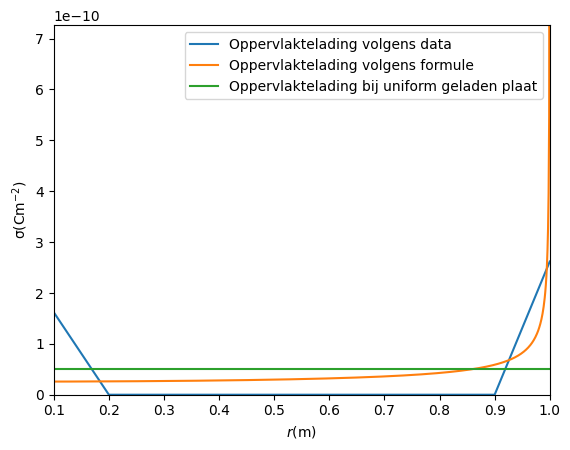

In [67]:
r_plot = np.linspace(0, disk_radius * 0.9999, 1000) #ontwijkt delen door nul
def sigma_formule(r, R, Q_tot):
    return Q_tot/(2*np.pi*R*np.sqrt(R**2 - r**2))

sigma_uniform_plot = np.ones(len(r_op_schijf))*sigma_uniform
sigma_formule_plot = sigma_formule(r_plot, disk_radius, Q_tot)
plt.figure()
plt.plot(r_op_schijf, sigma_langs_r, label='Oppervlaktelading volgens data')
plt.plot(r_plot, sigma_formule_plot, label='Oppervlaktelading volgens formule')
plt.plot(r_op_schijf, sigma_uniform_plot, label='Oppervlaktelading bij uniform geladen plaat')
plt.xlabel('$r$(m)')
plt.ylabel('σ(Cm$^{-2}$)')
plt.xlim(0.1, disk_radius)
plt.ylim(0, np.max(sigma_formule_plot) * 0.4)
plt.legend()

#### Vraag 3d: Het edge effect

1. Bepaal het maximum elektrische veld door de geleidende schijf in de simulatie.
2. Bepaal waar in de ruimte dit maximum zich bevindt.
3. Hoeveel hoger is dit maximum dan het elektrische veld in het midden van de schijf?
4. Print met een nette opmaak de waardes die je hier hebt berekend.
5. Leg uit wat de oorzaak van dit lokaal hoge elektrische veld is?


In [80]:
E_max = np.max(normE)

E_max_idx = find_idx_nearest(normE[z_idx_0 + 1, :], E_max) #Het maximum moet heel dicht bij de schijf liggen dus we bekijken alleen de norm heel dichtbij de schijf

positie_max = r_for_E[E_max_idx]

print('De positie van het maximum is: (z,r) = (0,%.0f). Op de rand van de schijf dus. Dit klopt echt want E_max = %.2f en normE[z_idx_0 + 1, E_max_idx] = %.2f. Hetzelfde dus' %(positie_max, E_max, normE[z_idx_0 + 1, E_max_idx]))

verhouding = E_max/norm_midden

print('Het maximum is %.2f maal hoger dan in het midden van de schijf' %(verhouding))

De positie van het maximum is: (z,r) = (0,1). Op de rand van de schijf dus. Dit klopt echt want E_max = 14.78 en normE[z_idx_0 + 1, E_max_idx] = 14.78. Hetzelfde dus
Het maximum is 1.62 maal hoger dan in het midden van de schijf


##### Antwoord 3d.5
Dit komt door het fenomeen genaamd het edge effect.  In een geleider kan lading vrij bewegen. De ladingen stoten elkaar af totdat alle ladingen op de rand zitten, waar de onderlinge afstand tussen de ladingen het grootst is en niet meer verder kunnen omdat het materiaal ophoudt

### 4) Twee geleidende platen op potentiaal $V_1$ and $-V_1$

In de cel hieronder wordt weer op dezelfde manier als in opdracht 3 de laplace vergelijking van deze situatie opgelost.

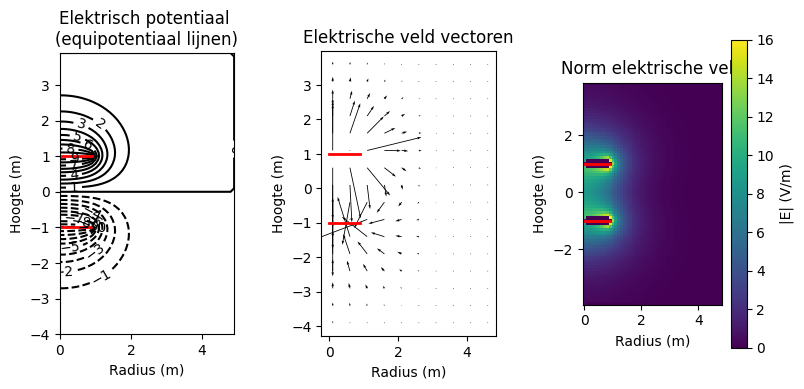

In [81]:
# Run deze cel en pas de cel aan in vraag 4f.
# Voor twee schijven
spacing_between_disks = 2  # (m)
z_pos_disk1 = spacing_between_disks/2  # z-coördinaat van de eerste geleidende schijf (m)
z_pos_disk2 = -spacing_between_disks/2  # z-coördinaat van de tweede geleidende schijf (m)
V1 = 10  # elektrische potentiaal van de eerste geleidende schijf (V)
V2 = -10  # elektrische potentiaal van de tweede geleidende schijf (V)

r, z, r_repmat, V, B, idx_R, idx_z1, idx_z2 = initialize_variables_Laplace(width_domain, disk_radius, height_domain, grid_step, z_pos_disk1, z_pos_disk2, V0, V1, V2)

"""--------------------------------------------------------------------
Veldberekening voor de twee geleidende schijven
"""
solve_Laplace_equation(V, B, r_repmat, grid_step, idx_z1, idx_z2, idx_R, V1, V2, 1e-3)
Er, Ez, normE = compute_E_disk(V, B, grid_step)
r_for_E = r[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de r-dimensie
z_for_E = z[1:-1]  # de centered finite-difference method kan E niet berekenen op het allereerste en allerlaatste gridpunt in de z-dimensie

""""---------------------------------------------------------
Plot het berekende veld
"""
plot_results_disk(Ez, Er, normE, V, r, z, grid_step, disk_radius, z_pos_disk1, z_pos_disk2)


#### Vraag 4a: Het $z$-component van het numeriek berekende elektrische veld van twee geleidende platen

1. Plot het $z$-component van het numeriek berekende elektrische veld op de as van de schijven.


Text(0, 0.5, 'E(V/m)')

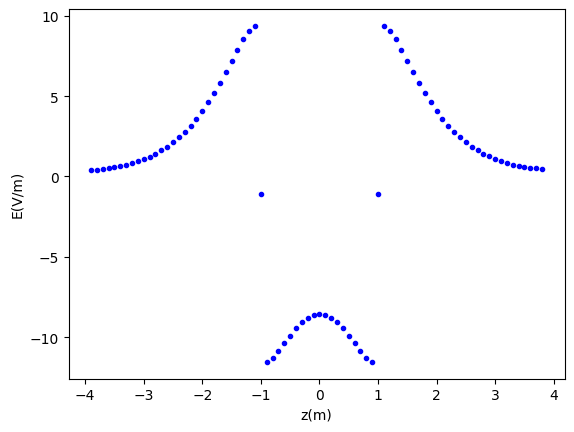

In [82]:
r_idx_0 = find_idx_nearest(r_for_E,0)
E_z_as = Ez[:,r_idx_0]


plt.figure()
plt.plot(z_for_E, E_z_as, 'b.', label = 'Elektrisch veld op de as',)
plt.xlabel('z(m)')
plt.ylabel('E(V/m)')

#### Vraag 4b: Verschillen tussen verschillende configuraties

1. Gegeven het potentiaal tussen twee geleidende platen, wat is het theoretische elektrische veld in elke regio? Laat dit zien met een afleiding en een schets die de verschillende regio's aangeeft.
2. Beschrijf het numeriek berekende elektrische veld op de as van de schijven, komt dit overeen met het theoretische elektrische veld?
3. Vergelijk het numeriek berekende elektrische veld tussen de twee schijven ($r=0$ and $z=0$) met dat van een enkele geleidende schijf op hetzelfde potentiaal(vraag 3a), welk voordeel heeft deze configuratie?

##### Antwoorden 4b

1. 
Dit is een afleiding voor oneindige platen, maar het is een goede benadering voor het veld bij het midden van de schijf: r = 0

Omdat er geen lading tussen de platen is geldt er:

$$
\nabla^2 V = 0
$$

De potentiaal hangt alleen van de z component af dus:

$$
\frac{d^2 V}{dz^2} = 0
$$

Twee keer integeren geeft:

$$
\frac{dV}{dz} = C_1
$$
$$
V(z) = C_1 z + C_2
$$

Kies het midden tussen de platen als $z = 0$:

- Onderste plaat: $z = -\frac{d}{2}$, $V = -V_1$
- Bovenste plaat: $z = +\frac{d}{2}$, $V = +V_1$

Invullen:

$$
+V_1 = C_1 \frac{d}{2} + C_2
$$

$$
-V_1 = -C_1 \frac{d}{2} + C_2
$$

Aftrekken van de vergelijkingen geeft:

$$
2V_1 = C_1 d
$$

Dus:

$$
C_1 = \frac{2V_1}{d}
$$

En:

$$
C_2 = 0
$$

Daarmee wordt de potentiaal:

$$
V(z) = \frac{2V_1}{d} z
$$

het elektrisch veld is in dit geval:

$$
E_z = -\frac{dV}{dz}
$$

Invullen geeft:

$$
E_z = -\frac{2V_1}{d}
$$

2. 
Het theoretische veld zou dus constant moeten zijn tussen de platen in. Dit is bij het numerieke model niet helemaal het geval, maar het is wel redelijk constant. Ook klopt het teken van het veld. Omdat er buiten de schijven geen geen netto lading aanwezig is, is het veld volgens de wet van Gauss 0. In het numerieke model met eindige schijven gaat het veld uiteindlijk ook naar 0.

3. Bij de enkele schijf is het veld bij z = 0 en r = 0 gelijk aan zowel ongeveer +10 V/m en -10 V/m. Dit komt doordat het een oneindig dunne schijf is, waardoor de waarde bij z = 0 tegelijkertijd de onderkant als de bovenkant van de schijf bekijkt. z = 0 en r = 0 bij de twee schijven zit precies tussen de schijven in. Hier heeft het veld een constante waarde van ongeveer -8 V/m. Het voordeel is dat je met twee schijven een vrij homogeen veld kan creeëren wat meer toepassingen heeft dan een inhomogeen veld

#### Vraag 4c: De capaciteit tussen twee geleidende platen

1. Bepaal de verwachte oppervlakte lading op de binnenzijde van een van de schijven.
2. Bepaal de verwachte totale lading op beide schijven.
3. Bepaal de capaciteit van deze situatie.
4. Print alle bepaalde waardes op een nette en overzichtelijke manier.

In [86]:
#ik weet niet of ik het op een numerieke of theoretische manier moet doen dus ik doe het allebie, beetje onduidelijk dit
z_idx_disk1 = find_idx_nearest(z_for_E,z_pos_disk1) -1#verzekerd dat er aan de onderkant van de bovenste schijf gekeken wordt
E_z0_r0 = Ez[z_idx_disk1,r_idx_0] # waarde van het veld bij z = 0 en r = 0 op disk 1. we hoeven geen Enorm te gebruiken omdat het veld loodrecht staat bij r = 0

opp_lading_binnen_num = 2 * E_z0_r0 * epsilon0 #formule voor oppervlakte lading

opp_lading_binnen_theo = (-2 * V1 * epsilon0)/(spacing_between_disks)
print('de oppervlakte lading volgens de theorie in het middelpunt is: %.2e C/m^2 en volgens het numerieke model: %.2e C/m^2' %(opp_lading_binnen_theo, opp_lading_binnen_num))

de oppervlakte lading volgens de theorie in het middelpunt is: -8.85e-11 C/m^2 en volgens het numerieke model: -2.04e-10 C/m^2


In [89]:
#Er is geen uniforme ladingsverdeling op een geleidende schijf dus moeten we de oppervlaktelading langs de straal r bepalen 
r_idx_R = find_idx_nearest(r_for_E, disk_radius)
veld_langs_r_disk1 = Ez[z_idx_disk1, :r_idx_R] 
sigma_langs_r_disk1 = 2 * epsilon0 * veld_langs_r_disk1
r_langs_disk1 = r_for_E[:r_idx_R + 1] #nu neemt hij ook r = 1 mee

r_langs_disk1_2 = np.append(r_langs_disk1, 0) #voegt een nul achteraan de lijst toe, dit is om het oppervlakte van de binnenste ring (een cirkel) goed te berekenen 
Q_tot_disk1 = 0

for i in range(len(sigma_langs_r_disk1)): #deze for loop telt voor 9 ringen en een binnenste cirkel met afzonderlijke ladingsdichtheid de lading bij elkaar op
    Q_tot_disk1 += sigma_langs_r_disk1[i]*np.pi*(r_langs_disk1_2[i]**2 - r_langs_disk1_2[i-1]**2)

#ik verwacht dat de totale lading op schijf 2 gelijk in grootte, maar met een tegenovergesteld teken aan schijf 1 is. 
print('de Totale lading op schijf 1 is: %.2e C en op schijf 2: %.2e C' %(Q_tot_disk1, -Q_tot_disk1))


de Totale lading op schijf 1 is: -6.42e-12 C en op schijf 2: 6.42e-12 C


In [91]:
#de capaciteit is gelijk aan Q/V
Capaciteit = np.abs(Q_tot_disk1/2*V1)

print('De capaciteit is: %.2e F' %(Capaciteit))

De capaciteit is: 3.21e-11 F


In [92]:
print('de oppervlakte lading volgens de theorie in het middelpunt is: %.2e C/m^2 en volgens het numerieke model: %.2e C/m^2' %(opp_lading_binnen_theo, opp_lading_binnen_num))
print('de Totale lading op schijf 1 is: %.2e C en op schijf 2: %.2e C' %(Q_tot_disk1, -Q_tot_disk1))
print('De capaciteit is: %.2e F' %(Capaciteit))

de oppervlakte lading volgens de theorie in het middelpunt is: -8.85e-11 C/m^2 en volgens het numerieke model: -2.04e-10 C/m^2
de Totale lading op schijf 1 is: -6.42e-12 C en op schijf 2: 6.42e-12 C
De capaciteit is: 3.21e-11 F


#### Vraag 4d: Theoretische oppervlakte lading

1. Is de oppervlaktelading aan de buitenkant van de schijven gelijk aan nul, beargumenteer waarom wel of niet.
2. Wat is het elektrische veld nabij het oppervlak van een geleider?

##### Antwoorden 4d
1.

In de benadering voor oneindige platen geldt dat het veld buiten de platen 0 is. Daarom geld volgens de formule:

$$
E_\perp = \frac{\sigma}{2\varepsilon_0}
$$

Als $E_\perp = 0$ omdat $Q_{encl} = 0$, dan volgt:

$$
\sigma = 0
$$

Dus alle lading zit aan de binnenkant en de buitenkant is 0

Voor eindige schijven geld dat het veld niet exact 0 is buiten de schijven waardoor er toch wel oppervlaktelading moet zijn.

2.

Net buiten het oppervlak van een geleider geldt dat het veld staat loodrecht op het oppervlak en voldoet aan:

$$
E_\perp = \frac{\sigma}{2\varepsilon_0}
$$

de parallele component aan het oppervlak is gelijk aan nul omdat het veld loodrecht staat

#### Vraag 4e: Numeriek berekende ladingsdichtheid

1. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net onder de onderste schijf.
2. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de onderkant van de onderste geleidende plaat.
3. Welke waarde heeft het $z$-component van het elektrische veld, op de as van de schijf net boven de onderste schijf.
4. Wat is volgens de formule uit vraag 4d 2 de ladingsdichtheid aan de bovenkant van de onderste geleidende plaat.
5. Print de bepaalde waardes op een nette en overzichtelijke manier.

In [93]:
z_idx_disk2_onder = find_idx_nearest(z_for_E, z_pos_disk2) - 1 #nu pakt hij net de waarde aan de buitenkant
r_idx_0 = find_idx_nearest(r_for_E, 0)

z_comp_onderste_schijf_onder = Ez[z_idx_disk2_onder, r_idx_0]

sigma_onderste_schijf_onder = 2 * z_comp_onderste_schijf_onder * epsilon0

z_idx_disk2_boven = find_idx_nearest(z_for_E, z_pos_disk2) + 1 #nu pakt hij net de waarde aan de bovenkant
z_comp_onderste_schijf_boven = Ez[z_idx_disk2_boven, r_idx_0]

sigma_onderste_schijf_boven = 2 * z_comp_onderste_schijf_boven * epsilon0

print('1. De waarde van het z-component op de onderkant van de onderste schijf is: %.2f V/m' %(z_comp_onderste_schijf_onder))
print('2. De waarde van de ladingsdichtheid op de onderkant van de onderste schijf is dan: %.2e C/m^2' %sigma_onderste_schijf_onder)
print('3. De waarde van het z-component op de bovenkant van de onderste schijf is: %.2f V/m' %(z_comp_onderste_schijf_boven))
print('4. De waarde van de ladingsdichtheid op de bovenkant van de onderste schijf is dan: %.2e C/m^2' %sigma_onderste_schijf_boven)
print('5. Zie hierboven')

1. De waarde van het z-component op de onderkant van de onderste schijf is: 9.37 V/m
2. De waarde van de ladingsdichtheid op de onderkant van de onderste schijf is dan: 1.66e-10 C/m^2
3. De waarde van het z-component op de bovenkant van de onderste schijf is: -11.54 V/m
4. De waarde van de ladingsdichtheid op de bovenkant van de onderste schijf is dan: -2.04e-10 C/m^2
5. Zie hierboven


#### Vraag 4f: Conclusies over de ladingsdichtheid op de twee schijven

1. Wat kan je uit vraag 4d en e concluderen over de daadwerkelijke lading op een schijf in tegenstelling tot de berekende lading in vraag 4c?
2. Wat is de invloed hiervan op de capaciteit berekend in vraag 4c?
3. Run de cel net onder het kopje vraag 4 opnieuw, maar dan met een kleinere afstand tussen de schijven, wat verandert er?

##### Antwoorden 4f

1. Uit de vragen blijkt dat er ook lading op de buitenkant van de schijven zit. Hier is tijdens het bereken van de totale lading niet op gelet. Daarom kunnen we concluderen dat er in totaal minder lading op de schijven zit. Aangezien de lading aan de buitenkant kleiner is en een tegenovergesteld teken heeft in vergelijking met de binnenkant.
2. Die wordt kleiner, aangezien de totale lading kleiner wordt
3. Het homogene veld tussen de schijven zal van hogere kwaliteit zijn dan op langere afstand. Dit komt doordat de schijven naar verhouding tot de afstand zijn 'gegroeid' hierdoor zal de benadering van oneindig grote schijven beter tot zijn recht komen waardoor het veld tussen de schijven een stuk homogener is. De theoretische grootte van het veld zal dan ook beter overeen komen met de numerieke grootte. Ook zal er naar verhouding minder lading op de buitenkant van de schijven zitten, waardoor het veld buiten de schijven kleiner zal zijn.

### 5) Voorbereidende opdracht voor de fysieke DEF ontwerpopdracht

In deze vraag zullen we ingaan op benodigde voorkennis voor de fysieke ontwerpopdracht "Maak een sensor met condensatoren". De formules die je in deze opdracht opstelt, heb je nodig gedurende de fysieke ontwerpopdracht.

In deze vraag zullen we kijken naar de ideale vlakke plaat condensator. Als de afstand tussen de platen veel kleiner is dan de grootte van de platen dan wordt de aanname gemaakt dat het veld tussen de platen constant is. Deze aanname zal niet helemaal overeenkomen met de werkelijkheid, zoals je in deze opdracht en de fysieke DEF ontwerpopdracht achter zal komen.

#### Vraag 5a: Functies voor de capaciteit van enkele opdrachten

1. Vind de formule voor de capaciteit van een vlakke plaat condensator en een cilinder condensator, onder de aanname dat de afstand tussen de platen veel kleiner is dan het oppervlakte van de condensator (vlakke plaat aanname).
2. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een vlakke plaat condensator als output heeft.
3. Vind de formule voor de capaciteit van een cilinder condensator onder de aanname dat de afstand tussen de binnen en buiten wand klein is.
4. Schrijf een python functie die de relevante parameters als input neemt en de capaciteit van een cilinder condensator als output heeft.

In [94]:
def vlakkeplaat(epsilonr,A, d): #A = oppervlakte, d is afstand tussen platen
    C = (epsilon0*epsilonr * A) / d 
    return C

def cilinder(epsilonr,L,a,b): #L = lengte, a is binnenstraal, b is buitenstraal
    C = (2*np.pi*epsilon0*epsilonr*L)/(np.log(b/a)) 
    return  C 



#### Vraag 5b: Capaciteit van enkele simpele condensatoren

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder staan een aantal condensatoren waarvoor jullie de capaciteit gaan berekenen. Print de capaciteit van elke condensator op een nette en overzichtelijke manier.
1. Bereken de capaciteit van een condensator gemaakt van twee vierkante plaatjes van 10 bij 10 cm met een plaatafstand van 1 mm en lucht als medium?
2. Bereken de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm met een lengte van 10 cm en lucht als medium?
3. Bereken de capaciteit van de condensatoren als de afstand tussen de platen verdubbeld
4. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven beschreven als ze gevuld zijn met water.
5. Bereken de capaciteit van de condensatoren uit 1 en 2 hierboven als de holte gevuld is met PVC.


In [95]:
print('vraag 1:',vlakkeplaat(1, 0.01, 0.001), 'F') #epsilon r van lucht = 1
print('vraag 2:', cilinder(1,0.1,0.0045,0.005), 'F')
print('vraag 3:', cilinder(1,0.1,0.0045,0.0055), 'F')
#epsilon r van water = 80.2
print('vraag 4: Plaat:',vlakkeplaat(80.2, 0.01, 0.001), 'F, cilinder:', cilinder(80.2,0.1,0.0045,0.005), 'F')
#epsilon r van PVC is ongeveer 3.1
print('vraag 5: Plaat:',vlakkeplaat(3.1, 0.01, 0.001), 'F, cilinder:', cilinder(3.1,0.1,0.0045,0.005), 'F')

vraag 1: 8.854e-11 F
vraag 2: 5.280092106841892e-11 F
vraag 3: 2.772269392979741e-11 F
vraag 4: Plaat: 7.100907999999999e-09 F, cilinder: 4.234633869687198e-09 F
vraag 5: Plaat: 2.7447399999999997e-10 F, cilinder: 1.6368285531209868e-10 F


#### Vraag 5c: Condensatoren uit het dagelijkse leven

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.
Hieronder is een foto te zien van condensatoren die in het dagelijkse leven gebruikt wordt.
Print de capaciteiten in deze vraag op een nette en overzichtelijke manier.
1. In figuur 5.1 is een condensator te zien van 1 $\micro$F, stel deze condensator kan geapproximeerd worden als een cilinder condensator met binnendiameter 5 mm en een buitendiameter van 6 mm. Bereken wat de lengte van de condensator dan zou zijn.
Stel dat we een vierkante plaat condensator hebben van 1 $\micro$F.
2. Bereken hoe lang de vlakke plaat condensator moet zijn als er 0.5 mm tussen de platen zit en de platen 6 mm breed zijn.

![figure 5.1](figures/Condensator_1_uF.jpg)

##### Figure: 5.1 Een 1 microfarad condensator.

In [96]:
def L_cilinder(Capaciteit,a,b,epsilonr):
    return (Capaciteit*np.log(b/a))/(2*np.pi*epsilon0*epsilonr)

print('De lengte van de condensator zou bij vraag 1', L_cilinder(1e-6,2.5e-3,3e-3,1), 'm') #dit is een behoorlijk groote waarde

#er vanuit gaande dat breedte niet lengte is:
def Lengte(Capaciteit,d,breedte,epsilonr):
    return (Capaciteit*d)/(epsilon0*epsilonr*breedte)

print('De lengte van de condensator zou bij vraag 2', Lengte(1e-6,0.5e-3,6e-3,1), 'm') #dit is een behoorlijk groote waarde




De lengte van de condensator zou bij vraag 1 3277.3183867142097 m
De lengte van de condensator zou bij vraag 2 9411.941871847 m


#### Vraag 5d: Hoge capaciteit condensatoren

1. Beargumenteer of je antwoorden uit vraag 5c realistisch zijn.
2. Bekijk je formule uit vraag 5a en bedenk hoe ze dit binnen in de condensator opgelost hebben.

##### Antwoorden 5d

1: De antwoorden zijn erg onrealistisch. Het lijkt niet alsof de condensator in het plaatje 3 km lang is, en ook een 'vierkante' condensator van 6 mm bij 9 km is niet erg aannemelijk.

2: Ze hebben dit waarschijnlijk opgelost door een medium te gebruiken met een veel hogere epsilon r, zodat het uiteindelijk op een redelijke waarde uitkomt.

#### Vraag 5e: Condensator in een achtbaan

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

Met het vak inleidend practicum zijn jullie naar Drievliet gegaan om daar metingen aan de attracties te doen. In Drievliet staat de achtbaan Formule X, deze achtbaan heeft een topsnelheid van 70 $\frac{\text{km}}{\text{h}}$ en bevat een treintje met plek voor 6 mensen. Deze snelheid bereikt de achtbaan door heel snel een karretje weg te schieten, dit wordt gedaan door de treintjes met een lineaire inductie motor te versnellen. Om de impact hiervan op het stroomnet te beperken gebruiken zij een condensator om de energie op te slaan en dan in een keer af te staan aan het treintje. In deze opdracht gaan we kijken wat de afmetingen zouden moeten zijn als ze vlakke plaat condensatoren zouden gebruiken.

De energie die opgeslagen is in een condensator kan berekend worden met de onderstaande formule.

$E = \frac{1}{2} CV^2$
Hierin is $E$ de totaal opgeslagen energie $C$ de capaciteit en $V$ het voltage waarop de condensator opereert, in dit geval $10$ $kV$.
1. Schat de massa van een treintje dat afgeschoten wordt.
2. Bereken de totale energie van het treintje na het afschieten.
3. Bereken de totale capaciteit van de condensator.
4. Bereken het oppervlakte van een vlakke plaat condensator die deze capaciteit heeft als die gevuld is met water en de platen 1 mm van elkaar afstaan.
5. Print alle berekende waardes op een nette en overzichtelijke manier.
6. Is dit realistisch, bedenk een manier hoe dit toch kan in een relatief klein volume.


In [97]:
massa = 2000 #kg, geschat
snelheid = 70 /3.6 #m/s
voltage = 10e3# V
tot_E = 1/2*massa*snelheid**2 #J, berekenen kinetische energie
Capaciteit = 2*tot_E/(voltage**2) #F
opp_condensator = (Capaciteit*1e-3)/(epsilon0*80.2) #m^2, 80.2 is epsilon r van water

print('De totale energie is', tot_E, 'J')
print('De totale capaciteit is', Capaciteit, 'F')
print('De oppervlakte is', opp_condensator, 'm^2')

De totale energie is 378086.4197530864 J
De totale capaciteit is 0.007561728395061728 F
De oppervlakte is 10648.959816211855 m^2


##### Antwoorden 5e

Dit is niet realistisch. Als we er van uit gaan dat in het echt de condensator ook gevuld is met water, kunnen meerdere condensators op elkaar gestapeld worden, waardoor je een veel kleiner oppervlakte nodig hebt dan eerst. 

#### Vraag 5f: Veranderende capaciteit

Gebruik in deze opdracht de functie die je bij vraag 5.1 geschreven hebt.

1. Bereken en plot de capaciteit van een vlakke plaat condensator van $10$ bij $10$ $cm$ waarbij de afstand tussen de platen lineair toeneemt van $0.5$ $mm$ tot $5$ $mm$.
2. Bereken en plot de capaciteit van een cilinder condensator met een binnendiameter van 9 mm en een buitendiameter van 10 mm en 10 cm lang, waarbij de binnencilinder er langzaam in 10 seconde uitgetrokken wordt.

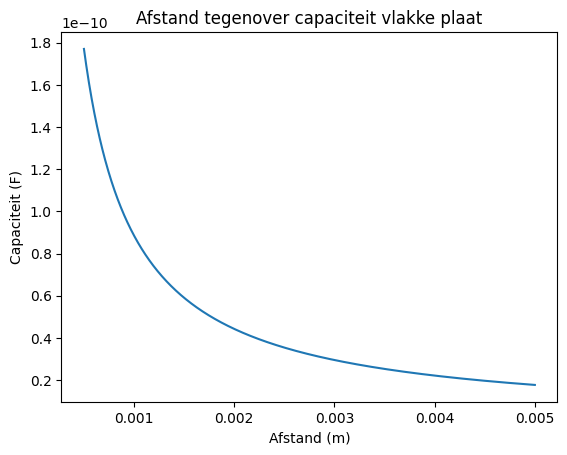

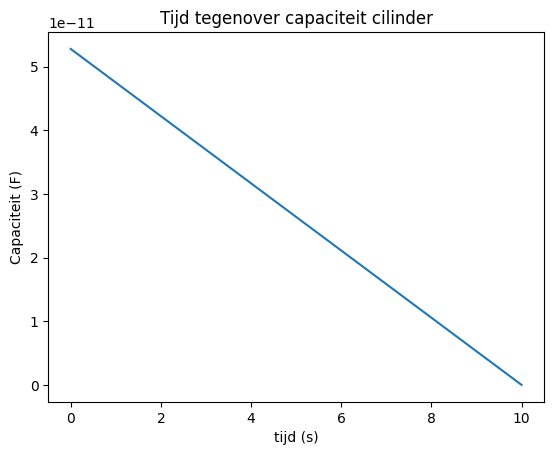

In [ ]:
afstand = np.linspace(0.5e-3,5e-3,1000)
plt.figure()
plt.plot(afstand,vlakkeplaat(1,0.01,afstand))
plt.xlabel('Afstand (m)')
plt.ylabel('Capaciteit (F)')
plt.title('Afstand tegenover capaciteit vlakke plaat')
plt.show

s=0.1 #m
t =10 #s
v=s/t #m/s

def lengte(l_0,v,t): #lengte van de cilinder
    return l_0-v*t

tijd=np.linspace(0,10,1000)

plt.figure()
plt.plot(tijd,cilinder(1,lengte(0.1,v,tijd),4.5e-3,5e-3))
plt.xlabel('tijd (s)')
plt.ylabel('Capaciteit (F)')
plt.title('Tijd tegenover capaciteit cilinder')
plt.show()

## Stop hier met werken tot na de fysieke ontwerpopdracht in week 3.

### 6) Reflectie opdracht voor na de fysieke ontwerpopdracht


Als het goed is, heeft ieder teamlid van deze simulatie-opdracht een andere opstelling ontworpen hebben tijdens de fysieke ontwerpopdracht. Kies in goed overleg voor deze opdracht een van jullie twee ontwerpen.

Voeg hieronder eerst een foto in van je opstelling die je gekozen hebt.

Jullie gaan in deze opdracht het verschil tussen jullie voorspelde verband en jullie uiteindelijke verkregen kalibratie grafiek proberen te verklaren. Er zijn hiervoor drie mogelijke paden die jullie kunnen kiezen om te onderzoeken, Kies deel a, b of c en werk die volledig uit voor jullie ontwerp. Let op je hoeft er maar een uit te werken.

Wij hebben gekozen voor de weegschaal opstelling. Met een stukje karton als diëlectricum waarvan uitgegaan is dat die zich gedraagd als een veer met een veerconstante
![figure 5.1](figures/opstelling_meting_2.jpeg)

#### Vraag 6a: Dunne laag niet meegerekende diëlektricum
Deze vraag is goed om te kiezen als je in je ontwerp een kleine laag extra materiaal hebt en deze tijdens de ontwerpopdracht niet hebben meegenomen in je theoretisch kalibratie grafiek.

1. Maak een nieuwe schets van je opstelling waarbij je de dikte van het extra diëlektricum meeneemt.
2. Leid de analytische oplossing af van de capaciteit van de hierboven getekende situatie.
3. Programmeer de analytische oplossing in python.
4. Maak hierna een plot van het kalibratiegrafiek, oude en nieuwe analytische oplossing in een grafiek.
5. Beschrijf en verklaar de verschillen tussen de grafieken.


##### Antwoorden 6a

*Laat in deze cel je analytische oplossing met schets zien, dit mag met foto's of via LATEX.*

In [ ]:
# Schrijf hier de code voor je oplossing. Gebruik hier je eerder gemaakte functies
# def condensator_extra_laag(#jouw variabelen): # Schrijf hier jouw functie
    ## je functie


### Maak hier je plot

##### Antwoorden 6a

*Beschrijf en verklaar je verschillen in deze markdown cel.*

#### Vraag 6b1: Lading op een condensator met het edge effect meegenomen

In deze opdracht gaan we verder in op het Edge effect en de invloed daarvan op de praktische capaciteit. Deze opdracht bouwt voort op de vraag 4.3.
Jullie hebben tijdens de ontwerpopdracht vierkante platen gebruikt in tegenstelling tot de ronde platen waarvoor de factoren in figure[label] zijn afgeleid. Er is onderzoek gedaan naar de factoren waarmee de praktische capaciteit vergeleken met de daadwerkelijke capaciteit verschilt dat onderzoek vind je hier: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=311759. Zoek in het onderzoek tabel 1 en formules 22 en 36 op.

1. Vergelijk de factor waarmee de schijf condensator verschilt met die van de vierkante plaat, kunnen we de vierkante plaat factor benaderen met de factor voor een disk condensator? Vergelijk het procentuele verschil tussen de factoren van de circulaire en vierkante platen, met de onzekerheden die in de meting zitten.



##### Antwoord 6b1

*Vergelijk hier de factoren tussen de circulaire en vierkante vlakke plaat condensatoren.*

de aspect ratio is: 0.0113 . Omdat deze kleiner is dan de kleinste aspect ratio uit de tabel gebruiken we een fit om de factoren te vinden voor kleinere aspect ratios
Het procentuele verschil is: 2.85 procent. Dit is klein vergeleken met de relatieve onzekerheid in de theoretische berekening van de capacitiet, die namelijk: 9.07 procent is
daarom kunnen we aannemen dat de factor van de schijf ongeveer gelijk is aan die van een vierkante plaat


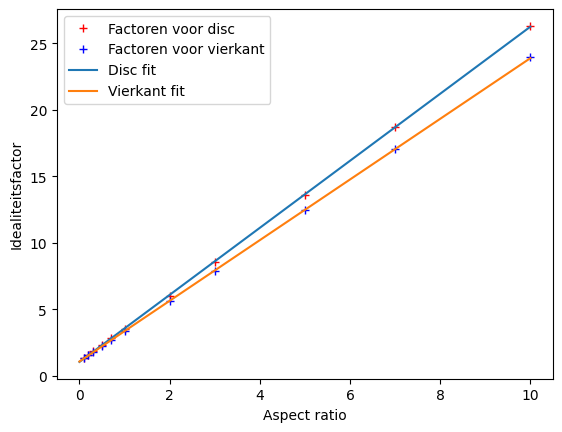

In [ ]:
eps_0 = 8.854e-12
eps_air = 1
eps_pap = 2.3
l_plaat = 0.1
A_plaat = l_plaat**2
d_karton = 1.13e-3 

aspect_ratio = d_karton/np.sqrt(A_plaat)
print('de aspect ratio is:',aspect_ratio,'. Omdat deze kleiner is dan de kleinste aspect ratio uit de tabel gebruiken we een fit om de factoren te vinden voor kleinere aspect ratios')

b = np.array([0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
cdn = np.array([1.31809, 1.58007, 1.83007, 2.31845, 2.80352, 3.53479, 6.01398, 8.52857, 13.59268, 18.67215, 26.30143])
csn = np.array([1.29980, 1.54987, 1.78426, 2.23581, 2.67950, 3.34336, 5.58217, 7.85246, 12.42957, 17.02431, 23.92769])

def fitfunc(b, A, B):
    return b * A + B

val_cdn, cov_cdn = curve_fit(fitfunc, b, cdn)
val_csn, cov_csn = curve_fit(fitfunc, b, csn)

x_val = np.linspace(0, np.max(b))

plt.figure()
plt.plot(b,cdn, 'r+', label='Factoren voor disc')
plt.plot(b,csn, 'b+',label='Factoren voor vierkant')
plt.plot(x_val, fitfunc(x_val, *val_cdn), label='Disc fit')
plt.plot(x_val, fitfunc(x_val, *val_csn), label='Vierkant fit')
plt.xlabel('Aspect ratio')
plt.ylabel('Idealiteitsfactor')
plt.legend()


factor_disc = fitfunc(aspect_ratio, *val_cdn)
factor_vierkant = fitfunc(aspect_ratio, *val_csn)

procentuele_verschil = np.abs((factor_disc - factor_vierkant)/factor_disc * 100)

u_l = 0.001 
u_d = 0.0001

procentuele_onzekerheid_capaciteit = np.sqrt(((2 * u_l)/l_plaat)**2 + (u_d/d_karton)**2) *100

print('Het procentuele verschil is:', np.round(procentuele_verschil,2),"procent. Dit is klein vergeleken met de relatieve onzekerheid in de theoretische berekening van de capacitiet, die namelijk:", np.round(procentuele_onzekerheid_capaciteit,2), 'procent is')
print("daarom kunnen we aannemen dat de factor van de schijf ongeveer gelijk is aan die van een vierkante plaat")

#### Vraag 6b2: Capaciteit van een condensator met het edge effect meegenomen

Vanaf hier nemen we aan dat factor van de circulaire platen ongeveer gelijk is aan de factor voor vierkante platen. De factor die de capaciteit van de vlakke plaat approximatie linkt aan de werkelijke capaciteit noemen we vanaf nu de idealiteitsfactor.

1. Bereken de daadwerkelijke theoretische capaciteit van de condensator uit de sanity check 3 van de fysieke ontwerpopdracht en print deze op een nette manier.
2. Vergelijk dit met de daadwerkelijke theoretische capaciteit met de capaciteit die je op de dag zelf hebt gemeten.

Vanaf hier gaan we verder met jullie sensor van de ontwerpopdracht "Maak een sensor met condensatoren":

3. Reken je theoretische kalibratie grafiek om met de idealiteitsfactor.
4. Vergelijk je nieuwe theoretische kalibratiegrafiek van je praktische kalibratiegrafiek van de dag zelf.

In [ ]:
def C_zonder_edge(A, d, eps_r):
    C = eps_0 * eps_r * A / d
    return C
    
C_zonder_edge_effect = C_zonder_edge(A_plaat, d_karton, eps_pap)

idealiteitsfactor = factor_disc
C_met_edge = idealiteitsfactor * C_zonder_edge_effect 
print("Berekende niet ideale capaciteit is", round(C_zonder_edge_effect,12), "F. En de werkelijke capaciteit is:", round(C_met_edge,12),'F')

Berekende niet ideale capaciteit is 1.8e-10 F. En de werkelijke capaciteit is: 1.91e-10 F


De daadwerkelijke gemeten capaciteit was 139 pF dus het verschilt 52 pF met de 191 pF van de theoretische capaciteit

Text(0, 0.5, 'Capaciteit(F)')

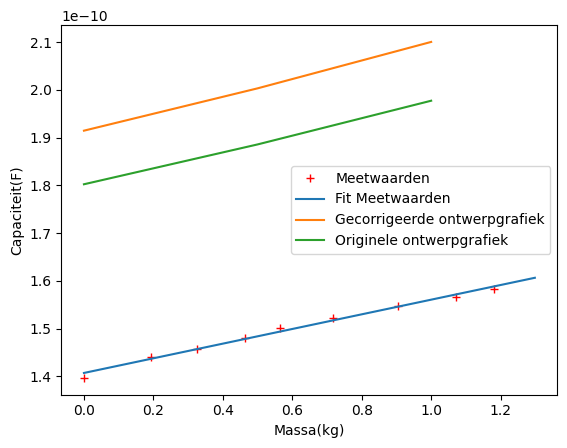

In [ ]:
massas = np.array([0,0.5638,0.463,1.1806,0.7176,0.7176+0.3548,0.9032,0.1924,0.3247])
Voltages = np.array([0.702,0.755,0.744,0.796,0.765,0.787,0.778,0.724,0.732])
# We beschouwen het karton als een veer met een constante veerconstante, waardoor de capacitiet linear toe zal nemen. 
#we verwachten dat de dikte van het karton onder het gewicht van 0,5 kilo 0.05 mm afneemt =. En onder 1 kilo 0.1mm lineair

massas_exp = np.array([0,0.5,1]) #data voor de voorspelde kalibratiegrafiek
diktes = np.array([d_karton, d_karton - 5e-5, d_karton - 10e-5])

def vlakkeplaat(A, d, eps_r, idealiteitsfactor):#formule voor capaciteit
    C = idealiteitsfactor * eps_0 * eps_r * A / d
    return C

Capaciteit = Voltages/(2*1000*8*np.pi*100e3)

x1 = np.linspace(0,1.1 * np.max(massas),100)

def fitfunc(x, A, B):
    return A + B * x

popt2, pcov2 = curve_fit(fitfunc, massas, Capaciteit)
plt.plot(massas, Capaciteit, 'r+', label='Meetwaarden')
plt.plot(x1, fitfunc(x1, *popt2), label= 'Fit Meetwaarden')
plt.plot(massas_exp, vlakkeplaat(A_plaat, diktes, eps_pap, idealiteitsfactor), label = 'Gecorrigeerde ontwerpgrafiek')
plt.plot(massas_exp, vlakkeplaat(A_plaat, diktes, eps_pap, 1), label = 'Originele ontwerpgrafiek')
plt.legend()
plt.xlabel('Massa(kg)')
plt.ylabel('Capaciteit(F)')

##### Antwoorden 6b2

De vergelijking gebruikt voor de sanity check van de condenstator is:

$$
C = \varepsilon_0 \varepsilon_r \frac{A}{d}
$$

En de formule waaruit beredeneerd is voor de voorspelde kalibratiegrafiek:

$$
F = -k x
$$

Met k de veerconstante

#### Vraag 6c: Niet linear diëlektricum optie 1

Niet alle materialen zijn een lineair diëlektricum. Een aantal van de materialen die sterk niet lineair gedrag vertonen zijn: sponzen, foam & rubber. Als je in je opdracht een materiaal gebruikt heb waarvan je verwacht dat het verband sterk niet lineair is kan dit een hele goede opdracht zijn.
| Materiaal |$\chi_2$   |
| :-------------|:-------------|
| Spons|  |

Als jouw materiaal hier niet tussen staat dan kan je zelf op zoek naar een waarde van $\chi_2$ in de literatuur.

#### Vraag 6c1

1. Leidt het D veld van de condensator af uit de wet van Gauss.
2. Vindt een analytische uitdrukking voor het elektrisch veld in termen van het D veld.

##### Antwoorden 6c 1

*Antwoord vraag 6c 1.*

#### Vraag 6c2

1. Programmeer je oplossingen voor het D en E veld in python, gebruik het D veld uit je fysieke ontwerpopdracht.

Als je het elektrische veld van een vierkante vlakke plaat condensator weet kan je de capaciteit berekenen met de onderstaande formule:
$C = \frac{A
E_z \epsilon_0}{\Delta V}$

2. Plot de capaciteit van het niet lineaire diëlektricum, het theoretische kalibratiegrafiek en de uiteindelijke kalibratiegrafiek van de fysieke ontwerpopdracht.
3. Verklaar verschillen tussen de grafieken.

In [ ]:
 # Pas deze code aan zodat jouw opstelling doorgerekend wordt
def E_condensator(x1, x2, D):
    return None

#### Vraag 7

Hoeveel van de afwijking tussen je metingen en je oorspronkelijke voorspelde kalibratiegrafiek wordt verklaard door wat je bij vraag 6 hebt uitgerekend? Kan je een (aantal) elektrisch veld en capaciteit gerelateerde reden(en) verzinnen wat de rest van de afwijking tussen meting en voorspelde kalibratiegrafiek kan verklaren.

##### Antwoorden 7

Geen van de afwijking tussen de oorspronkeljk voorspelde kalibratiegrafiek en de metingen kan door vraag 6 verklaard worden, aangezien de oorspronkelijke voorspelling dichter bij de metingen zit dan de voorspelling uit vraag 6.

Een reden is dat er stroom loopt door de arduino, waardoor elektrische velden gegenereerd worden. Die elektrische velden kunnen al invloed hebben op de capaciteit, waar door er een verschi ontstaat tussen de voorspellingen en wat er opgemeten is. 
Een andere reden is dat, hoewel dit wel is aangenomen, het verband tussen de massa en de niet lineair is, waardoor de capaciteit anders gaat dan verwacht.
Een laatste reden is dat de relatieve permittiviteit van het karton niet perfect gevonden was, waardoor capaciteit ook anders was dan verwacht. 